In [1]:
# Import all necessary libraries
import pynbody
import numpy as np
import h5py
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pynbody.array import SimArray
import tqdm.auto as tqdm

# Import the snapshot
s = pynbody.load('/home/christenc/Storage/Cosmo/storm.cosmo25cmb/storm.cosmo25cmb.4096g5HbwK1BH/storm.cosmo25cmb.4096g5HbwK1BH.004096/storm.cosmo25cmb.4096g5HbwK1BH.004096')

# Access the halos and their unique IDs
h = s.halos()
h.load_all()
unique_halo_ids = list(h.keys()) # mixed in terms of size

# Identify the main halo (halo with most stars)
main_halo = h[unique_halo_ids[0]]
iterations = len(unique_halo_ids) - 1
for i in range(1, iterations):
    if len(main_halo) < len(h[unique_halo_ids[i]]):
        main_halo = h[unique_halo_ids[i]]

# Identify the center of the galaxy
pynbody.analysis.halo.center
cen = main_halo.mean_by_mass('pos')

# Import all the star particles (sp) within a radius of 200kpc from the center of the galaxy
sp = s[pynbody.filt.Sphere(SimArray([200], "kpc"), cen)].load_copy()

# Initiate physical units
s.physical_units()


In [2]:
with h5py.File('/home/christenc/Storage/Cosmo/storm.cosmo25cmb/storm.cosmo25cmb.4096g5HbwK1BH/storm.cosmo25cmb.4096g5HbwK1BH_allhalostardata_upd.h5','r') as f:
    hostids = f['host_IDs'].asstr()[:]  # host IDs
    partids_h5 = f['particle_IDs'][:]  # particle IDs from h5

partids_snap = sp.s['iord'] # particle IDs from snapshot

In [3]:
m = sp.s['mass'] #Gets key data for all snapshot IDs

x = sp.s['pos'][:, 0]
y = sp.s['pos'][:, 1]
z = sp.s['pos'][:, 2]

vx = sp.s['vel'][:, 0]
vy = sp.s['vel'][:, 1]
vz = sp.s['vel'][:, 2]

#Creates arrays for all particles
particle_array_all = np.column_stack((m,x,y,z,vx,vy,vz))
pos_array_all = particle_array_all[:, 1:4]

#Centers all particles, using cm
total_mass_all=0
for i in range(len(particle_array_all)):
    total_mass_all = total_mass_all + particle_array_all[i][0]
   
cm_current_all = [0,0,0]
for i in range(len(particle_array_all)):
    cm_current_all = cm_current_all + particle_array_all[i][0] * particle_array_all[i][1:4]
cm_all = cm_current_all/total_mass_all

pos_array_centered_all = pos_array_all - cm_all

In [4]:
def axis_transform(host_ids):

    '''Calculates angular momentum and center of mass from host_id(s) of interest to get new axes. Transforms all data 
    into new coordinate system. Outputs transformed data, as well as transformed data for halo_id of interest separately.
    
    host_id = host_id of halo to calibrate axes around'''
    

    #Creates filtered arrays. n rows. 7 columns (mass, x, y, z, vx, vy, and vz)
    
    _, idloc_snap, idloc_h5 = np.intersect1d(partids_snap, partids_h5, return_indices = True) #Returns position locations of shared ids
                                                                                              #partids_h5 in partids_snap, partids_snap in
                                                                                              #partuds_h5
    
    progenitor = hostids[idloc_h5] #Returns progenitor for each shared id
    mask = np.isin(progenitor, host_ids) #Checks that each progenitor is desired
    
    m_halo = m[idloc_snap][mask] #Selects only the desired progenitors
    x_halo = x[idloc_snap][mask]
    y_halo = y[idloc_snap][mask]
    z_halo = z[idloc_snap][mask]
    vx_halo = vx[idloc_snap][mask]
    vy_halo = vy[idloc_snap][mask]
    vz_halo = vz[idloc_snap][mask]


    #Calculates new position array
    particle_array_halo = np.column_stack((m_halo,x_halo,y_halo,z_halo,vx_halo,vy_halo,vz_halo)) #Rows are particles, columns are characteristics
    pos_array_halo = particle_array_halo[:, 1:4]
    pos_array_centered_halo = pos_array_halo - cm_all #VERY INTENTIONALLY NOT cm_halo
    
    #Calculates ang_mom and c_m to align axes
    total_mass_halo=0
    for i in range(len(particle_array_halo)):
        total_mass_halo = total_mass_halo + particle_array_halo[i][0]
   
    cm_current_halo = [0,0,0]
    for i in range(len(particle_array_halo)):
        cm_current_halo = cm_current_halo + particle_array_halo[i][0] * particle_array_halo[i][1:4]
    cm_halo = cm_current_halo/total_mass_halo
    
    ang_mom_halo = [0,0,0]
    for i in range(len(particle_array_halo)):
        ang_mom_halo = ang_mom_halo + particle_array_halo[i][0] * np.cross(particle_array_halo[i][1:4], particle_array_halo[i][4:7])



    
    #Gets new axes (all normalized vectors).
    z_prime = ang_mom_halo/np.linalg.norm(ang_mom_halo)
    
    y_prime_unnormed = np.cross(ang_mom_halo, cm_halo)
    y_prime =  y_prime_unnormed/np.linalg.norm(y_prime_unnormed)
    
    x_prime = np.cross(z_prime, y_prime)

    #Transforms data using new axdes     
    transform_matrix = np.row_stack((x_prime, y_prime, z_prime)) #rows are basis vectors

    new_pos_array_all = np.matmul(transform_matrix, pos_array_centered_all.T) #multiplies 3x3 matrix by 3xn matrix. Result is 3xn transformed vectors.
    new_pos_array_halo = np.matmul(transform_matrix, pos_array_centered_halo.T)#same as above, but with only stars from halo of intereset
    
    return new_pos_array_all, new_pos_array_halo



In [7]:
galaxy = 'storm_2'
halo = '2304_133'

In [5]:
def angle_view(host_ids, declination, azimuthal,plot = True, save = False, axis_of_rotation = None, angle = 0, limits = None, n=0):

    '''Calculates 2d image coordinates based on angle of view. Plots graph. Many optional parameters for moviemaking ease

    host_ids = hostid(s) of halo to calibrate axes around, as well as color differently
    declination = camera angle measured down from z axis
    azimuthal = camera angle measured counterclockwise from x axis in xy plane
    
    Below are largely movie features 
    
    plot = Whether to display plot on Jupyter or not.
    save = Whether to save plot to file system
    axis_of_rotation = x,y, or z. Axis camera is rotation around.
    angle = Angle from current camera position to default camera position (depends on what type of movie you're making
    limits = 1x4 array of [min image(x), max image(x), min image(y), max image(y)]
    n = index of what image. Stored like 000 for first image, and 010 for 11th image for example.
    
    '''

    pos_array_all, pos_array_halo = axis_transform(host_ids) #unpacks axis_transform

    #Spherical Coordinates
    theta = (declination) * np.pi/180 
    fi = azimuthal * np.pi/180

    #Uses generalized matrix to find 2d projected image from any given camera angle 
    project_matrix = np.array([[-np.sin(fi),                np.cos(fi),             0            ],
                             [-np.cos(theta)*np.cos(fi), -np.cos(theta)*np.sin(fi), np.sin(theta)]])

    project_pos_array_all = np.matmul(project_matrix, pos_array_all) #applies 2x3 transformation to 3xn data. Result is 2xn data 
    project_pos_array_halo = np.matmul(project_matrix, pos_array_halo) #same as above, just for halo of interest, so color can be different

    #plotting. Dual functions of normal projection and movie making
    fig,ax  = plt.subplots()
    ax.scatter (project_pos_array_all[0], project_pos_array_all[1], s =1)
    ax.scatter (project_pos_array_halo[0], project_pos_array_halo[1], s =1, color='red') #different halo color

    #Optional parameters
    if axis_of_rotation != None:
        ax.set_title(f"{axis_of_rotation}_{angle}")

    if limits != None:
        plt.xlim(limits[0], limits[1])
        plt.ylim(limits[2], limits[3])

    if save == True:
        plt.savefig(f"/home/otteleno/MAP/Movies/{galaxy}/{axis_of_rotation}/{axis_of_rotation}_{n}.png")
    
    if plot == True:
        plt.show()
    else:
        plt.close()
        

    
    return 

    

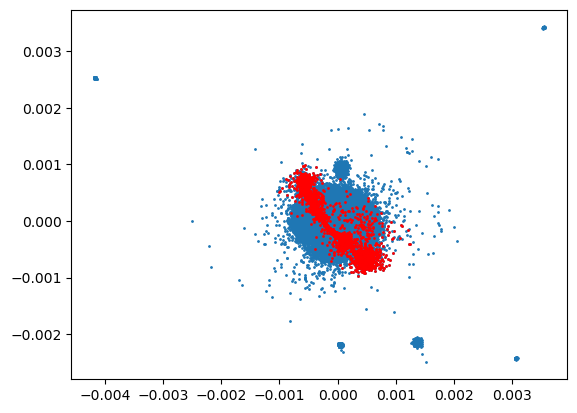

In [8]:
angle_view(halo, 0,0)

In [9]:
#Movie Maker

number_of_snapshots = 72
radius = .0025 #Default is to autoscale

for i in range(number_of_snapshots): # Rotation in x-y plane around z-axis
    angle_incs = int(360/number_of_snapshots)
    current_angle_inc = angle_incs*i
    angle_view(halo,90,angle_incs*i,save = True, axis_of_rotation = 'z', angle = current_angle_inc, 
               limits = [-radius, radius, -radius, radius], n=f"{i:03}", plot = False)


for i in range(number_of_snapshots): #Rotation in x-z plane around y-axis
    angle_incs = int(360/number_of_snapshots)
    current_angle_inc = angle_incs*i
    angle_view(halo,angle_incs*i,0,save = True, axis_of_rotation = 'y', angle = current_angle_inc,
               limits = [-radius, radius, -radius, radius], n=f"{i:03}", plot = False)


for i in range(number_of_snapshots): #Rotation in y-z plane around x-axis
    angle_incs = int(360/number_of_snapshots)
    current_angle_inc = angle_incs*i
    angle_view(halo,angle_incs*i,90,save = True, axis_of_rotation = 'x', angle = current_angle_inc,
               limits = [-radius, radius, -radius, radius], n=f"{i:03}", plot = False)
    